# Bước 02: Phân tích khám phá dữ liệu (EDA) — tập huấn luyện v5

Chạy lại toàn bộ EDA trên **dữ liệu v5 hiện hành**, thay cho các notebook EDA cũ trong
`notebooks/EDA/` vốn chạy trên bộ dữ liệu trước.

**Đầu vào:** `data/model/v5/02_split/train/v5_train.parquet` — **chỉ tập huấn luyện**.

> Không dùng toàn tập. EDA này dẫn tới các quyết định sinh đặc trưng, nên nếu nhìn cả tập test
> thì tập test đã tham gia vào thiết kế mô hình — trái với nguyên tắc niêm phong ở Mục 1.5.
> Cùng nguyên tắc mà `03_2` dùng khi tính `site_scale` và `cs_factor` riêng cho từng fold.

**Sinh ra 4 hình cho báo cáo:**

| Hình | Nội dung | Loại phân tích |
|---|---|---|
| 1 | Phân bố sản lượng — độ lệch, độ nhọn, tỷ lệ giá trị 0 | đơn biến |
| 2 | Ngày trời quang so với ngày nhiều mây | đơn biến theo thời gian |
| 3 | Tự tương quan ACF và PACF | đơn biến theo độ trễ |
| 4 | Ma trận tương quan Spearman ban ngày | đa biến |

**Không làm ở đây:** chẩn đoán đa cộng tuyến VIF — thuộc `04_vif_diagnostics.ipynb`, vì VIF
cần chạy sau khi đã sinh đủ đặc trưng ở `03_1`, `03_2`, `03_3`.

## 1. Nạp thư viện và khai báo phạm vi

In [2]:
import os
for _b in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(_b, "6")

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 150

# CHI doc tap HUAN LUYEN - xem ghi chu o o dau notebook.
VAO = "../../data/model/v5/02_split/train/v5_train.parquet"
RA  = "../../data/model/v5/02_EDA"
os.makedirs(RA, exist_ok=True)

SITE, TS, TARGET = "site_id", "timestamp", "energy_generated_kwh"
TRAM_BO = [19, 24]        # hai tram bi loai khoi pham vi cham diem, xem Muc 1.1

print(f"Doc : {VAO}")
print(f"Ghi : {RA}")
print(f"Loai khoi EDA: tram {TRAM_BO}")

Doc : ../../data/model/v5/02_split/train/v5_train.parquet
Ghi : ../../data/model/v5/02_EDA
Loai khoi EDA: tram [19, 24]


## 2. Đọc dữ liệu và khoanh vùng phân tích

Ba phạm vi được tách riêng ngay từ đầu để mọi con số phía sau đều nói rõ nó thuộc phạm vi nào:

- **Toàn tập huấn luyện** — dùng cho phân bố tổng thể
- **Ban ngày** — `is_daylight = True`
- **Đo thật ban ngày** — thêm điều kiện `energy_source = measured`, đây là phạm vi mà báo cáo dùng để tính chỉ số

In [3]:
COT = [SITE, TS, TARGET, "shortwave_radiation", "is_daylight", "energy_source",
       "temperature_c", "cloud_cover_total", "diffuse_solar_radiation",
       "direct_normal_irradiance", "exclude_from_training", "outlier_group"]

df = pd.read_parquet(VAO, columns=COT)
print(f"Doc vao          : {len(df):,} dong x {df.shape[1]} cot | {df[SITE].nunique()} tram")
print(f"Khoang thoi gian : {df[TS].min()} -> {df[TS].max()}")

df = df[~df[SITE].isin(TRAM_BO)].copy()
print(f"Sau khi bo tram {TRAM_BO}: {len(df):,} dong | {df[SITE].nunique()} tram")

_ngay = df["is_daylight"].fillna(False).astype(bool)
_do   = df["energy_source"].eq("measured")

pham_vi = {
    "toan bo":            df,
    "ban ngay":           df[_ngay],
    "do that ban ngay":   df[_ngay & _do],
}
print()
for ten, z in pham_vi.items():
    print(f"   {ten:<20} {len(z):>10,} dong  ({len(z)/len(df)*100:5.2f}%)")

Doc vao          : 1,550,856 dong x 12 cot | 42 tram
Khoang thoi gian : 2020-01-01 00:15:00 -> 2021-06-22 01:00:00
Sau khi bo tram [19, 24]: 1,480,000 dong | 40 tram

   toan bo               1,480,000 dong  (100.00%)
   ban ngay                742,116 dong  (50.14%)
   do that ban ngay        606,112 dong  (40.95%)


## 3. Phân bố đơn biến của sản lượng

Kiểm hai đặc điểm: **lệch phải** (skewness) và **độ nhọn** (kurtosis). Cả hai quyết định việc
có phải chuẩn hoá mục tiêu hay không.

In [4]:
bang = []
for ten, z in pham_vi.items():
    v = z[TARGET].to_numpy(dtype=float)
    v = v[~np.isnan(v)]
    bang.append({
        "pham_vi": ten, "so_dong": len(v),
        "trung_binh": round(float(v.mean()), 4),
        "trung_vi":   round(float(np.median(v)), 4),
        "do_lech_chuan": round(float(v.std()), 4),
        "skewness": round(float(stats.skew(v)), 4),
        "kurtosis": round(float(stats.kurtosis(v, fisher=True)), 4),
        "ty_le_bang_0_%": round(float((v == 0).mean() * 100), 2),
        "p99": round(float(np.quantile(v, 0.99)), 4),
    })
kq_phan_bo = pd.DataFrame(bang)

print("--- THONG KE MO TA SAN LUONG THEO TUNG PHAM VI ---")
print(kq_phan_bo.to_string(index=False))
kq_phan_bo.to_csv(f"{RA}/eda_thong_ke_mo_ta.csv", index=False)

_a = kq_phan_bo.iloc[0]
print(f"\nDoc ket qua (toan bo tap huan luyen):")
print(f"   Skewness {_a['skewness']:.4f} -> {'LECH PHAI MANH' if _a['skewness'] > 1.0 else 'gan doi xung'}")
print(f"   Kurtosis {_a['kurtosis']:.4f} -> {'DUOI NHON' if _a['kurtosis'] > 3.0 else 'binh thuong'}")
print(f"   {_a['ty_le_bang_0_%']:.2f}% quan sat bang 0 - chu yeu la ban dem")

--- THONG KE MO TA SAN LUONG THEO TUNG PHAM VI ---
         pham_vi  so_dong  trung_binh  trung_vi  do_lech_chuan  skewness  kurtosis  ty_le_bang_0_%     p99
         toan bo  1480000      3.0600    0.0000         8.2036    6.0575   47.3227           52.47 44.3750
        ban ngay   742116      6.0995    2.7383        10.7554    4.5130   25.3731            6.04 64.6094
do that ban ngay   606112      6.4765    3.2188        10.6452    4.4313   24.5310            0.00 63.8663

Doc ket qua (toan bo tap huan luyen):
   Skewness 6.0575 -> LECH PHAI MANH
   Kurtosis 47.3227 -> DUOI NHON
   52.47% quan sat bang 0 - chu yeu la ban dem


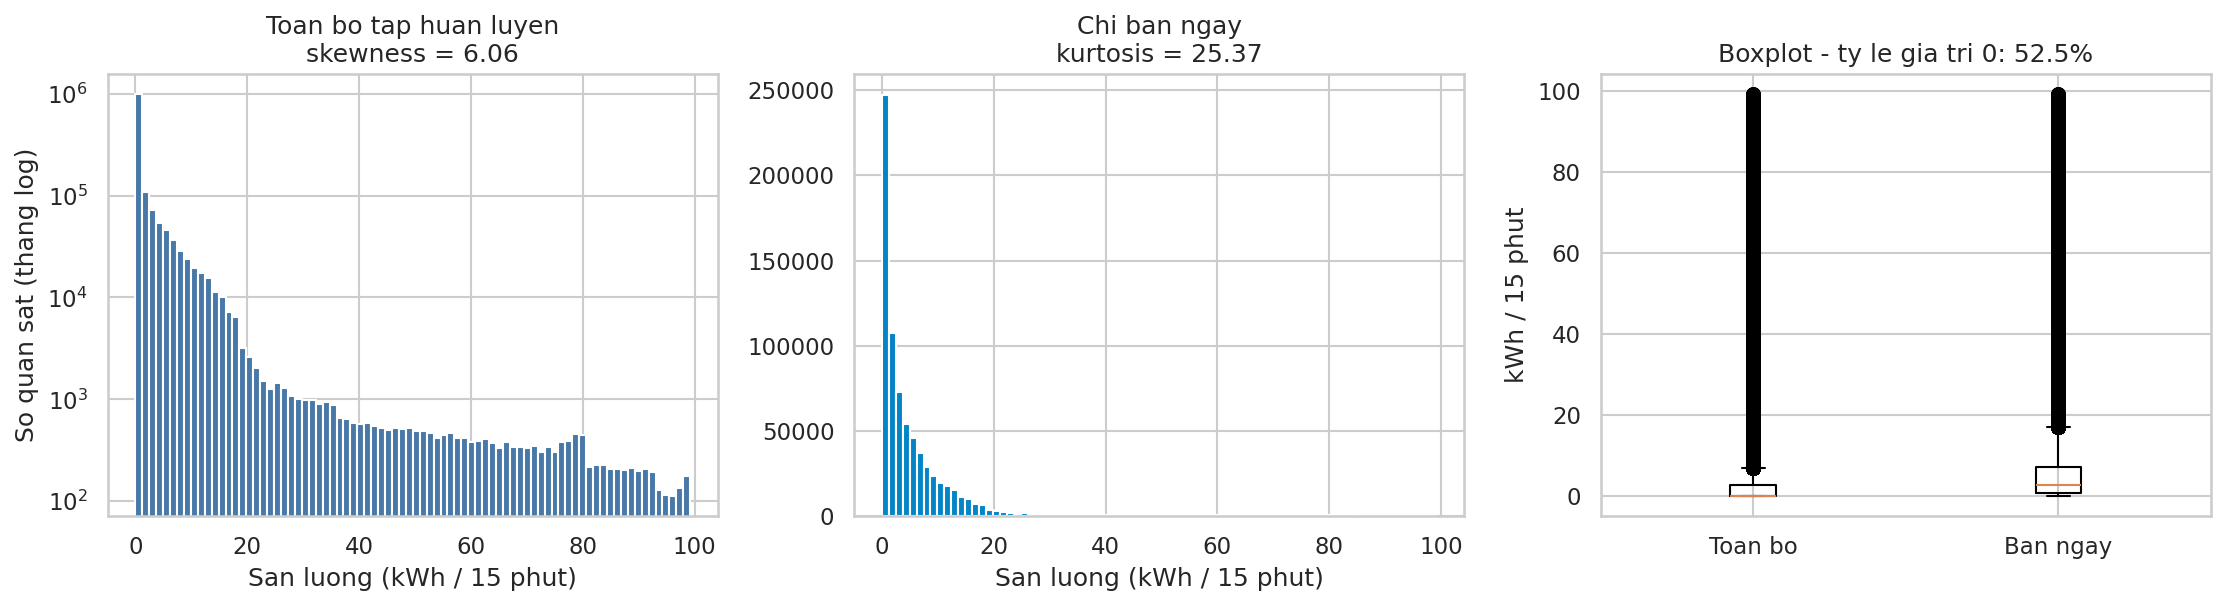

Da ghi: ../../data/model/v5/02_EDA/eda_phan_bo_don_bien.png


In [5]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
_tb = pham_vi["toan bo"][TARGET].dropna().to_numpy(float)
_bn = pham_vi["ban ngay"][TARGET].dropna().to_numpy(float)

ax[0].hist(_tb, bins=80, color="#4878a8")
ax[0].set_yscale("log")
ax[0].set_title(f"Toan bo tap huan luyen\nskewness = {stats.skew(_tb):.2f}")
ax[0].set_xlabel("San luong (kWh / 15 phut)"); ax[0].set_ylabel("So quan sat (thang log)")

ax[1].hist(_bn, bins=80, color="#0284c7")
ax[1].set_title(f"Chi ban ngay\nkurtosis = {stats.kurtosis(_bn):.2f}")
ax[1].set_xlabel("San luong (kWh / 15 phut)")

ax[2].boxplot([_tb, _bn], tick_labels=["Toan bo", "Ban ngay"], showfliers=True)
ax[2].set_title(f"Boxplot - ty le gia tri 0: {(_tb == 0).mean()*100:.1f}%")
ax[2].set_ylabel("kWh / 15 phut")

plt.tight_layout()
plt.savefig(f"{RA}/eda_phan_bo_don_bien.png", bbox_inches="tight")
plt.show()
print(f"Da ghi: {RA}/eda_phan_bo_don_bien.png")

## 4. Mẫu hình phát điện: ngày trời quang so với ngày nhiều mây

Đo trực tiếp mức sụt bức xạ lớn nhất trong **một bước 15 phút**, rồi vẽ hai ngày tương phản.

Tram 27 | 283 ngay dat dieu kien | 71 ngay nhieu nang
   Ngay troi quang: 2020-10-02 | do gap 0.0031
   Ngay nhieu may : 2020-12-23 | do gap 0.0926


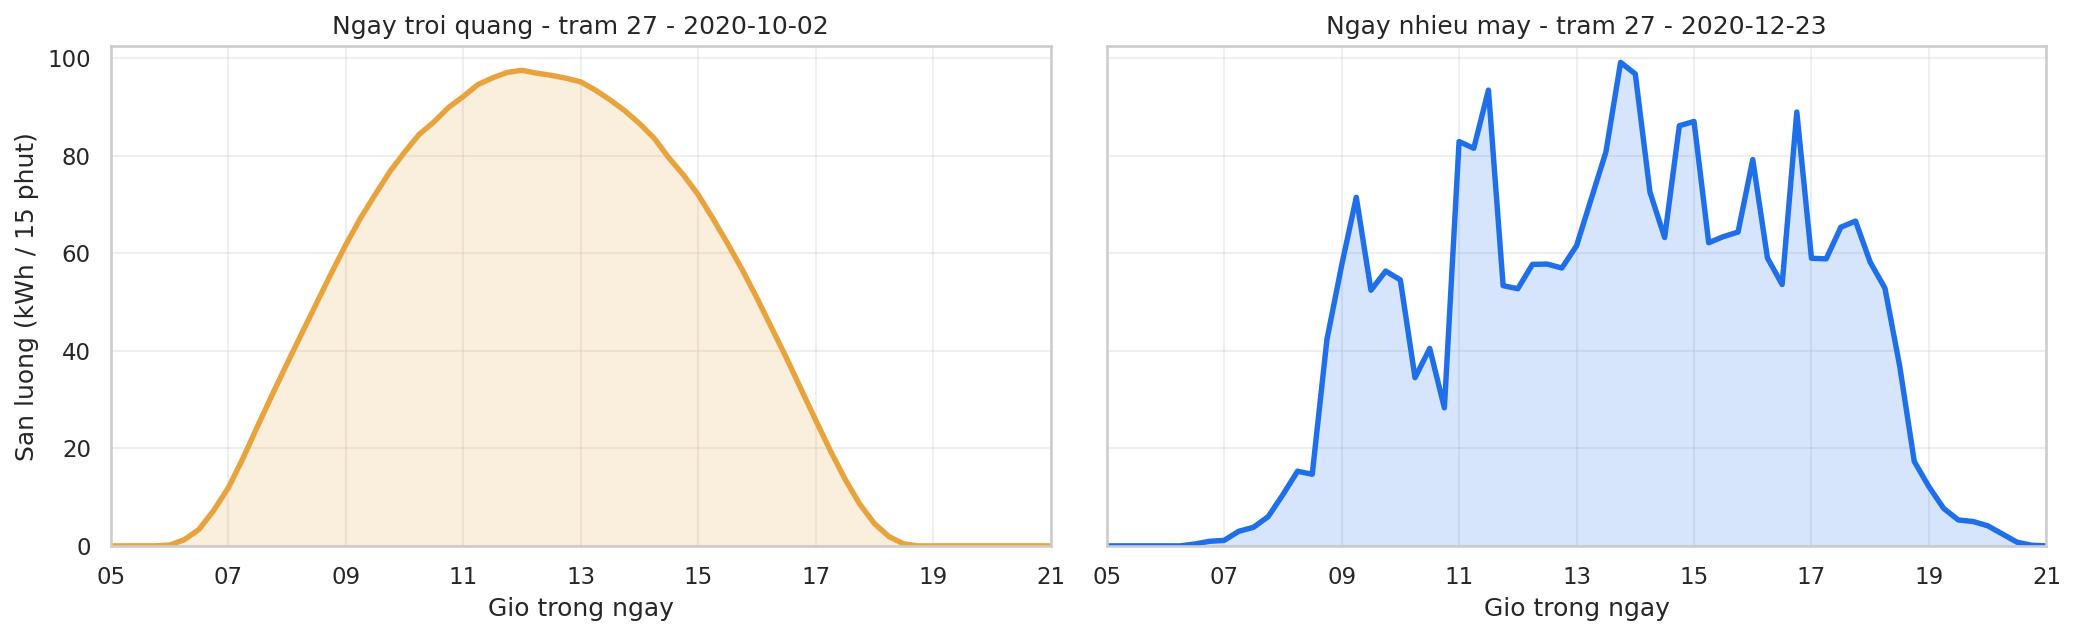


Da ghi: ../../data/model/v5/02_EDA/eda_mau_hinh_phat_dien.png


In [6]:
# Tram phat manh nhat.
_s = int(df.groupby(SITE)[TARGET].mean().idxmax())

# Chi xet ngay co it nhat 40 moc DO THAT ban ngay va du 96 moc trong ngay,
# de hinh khong roi vao ngay do tang ETL dien khuyet.
_d = df[df[SITE].eq(_s)].sort_values(TS).copy()
_d["ngay"] = _d[TS].dt.normalize()

_dn = _d[_d["is_daylight"].fillna(False).astype(bool)
         & _d["energy_source"].eq("measured")]
_du = _dn.groupby("ngay").size()
_dem = _d.groupby("ngay").size()
_ngay_dat = set(_du[_du >= 40].index) & set(_dem[_dem == 96].index)
_d = _d[_d["ngay"].isin(_ngay_dat)]

# Hai ngay tuong phan, chon bang tieu chi do duoc tren chinh du lieu.
#   Do gap = trung binh |sai phan bac hai| cua san luong, chia cho dinh trong ngay
#            -> cang nho duong cang muot, khong phu thuoc quy mo tram.
#   Ngay troi quang = do gap NHO nhat trong nhom ngay nhieu nang (tong san luong
#                     thuoc phan tu tren), de khong chon nham ngay am u phang li.
#   Ngay nhieu may  = do gap LON nhat trong cung nhom ngay do.
_g = _d.groupby("ngay")
_do_gap = _g[TARGET].apply(lambda v: v.diff().diff().abs().mean() / max(v.max(), 1e-9))
_tong = _g[TARGET].sum()
_ngay_nang = _tong[_tong >= _tong.quantile(0.75)].index

ngay_quang = _do_gap.loc[_ngay_nang].idxmin()
ngay_may = _do_gap.loc[_ngay_nang].idxmax()

print(f"Tram {_s} | {_d['ngay'].nunique()} ngay dat dieu kien"
      f" | {len(_ngay_nang)} ngay nhieu nang")
print(f"   Ngay troi quang: {ngay_quang.date()} | do gap {_do_gap[ngay_quang]:.4f}")
print(f"   Ngay nhieu may : {ngay_may.date()} | do gap {_do_gap[ngay_may]:.4f}")

# Hinh chi ve SAN LUONG. Buc xa la du lieu mot gio, ve chong len chuoi 15 phut
# se doc ra do lech pha khong co that; quan he buc xa - san luong da duoc do
# bang he so tuong quan o muc 6 duoi day.
import matplotlib.dates as mdates

fig, ax = plt.subplots(1, 2, figsize=(14, 4.4), sharey=True)
for k, (ng, ten, mau) in enumerate([(ngay_quang, "Ngay troi quang", "#e8a33d"),
                                    (ngay_may,   "Ngay nhieu may",  "#1f6feb")]):
    z = _d[_d["ngay"].eq(ng)].sort_values(TS)
    a = ax[k]
    a.plot(z[TS], z[TARGET], color=mau, lw=2.6)
    a.fill_between(z[TS], z[TARGET], color=mau, alpha=0.18)
    a.set_title(f"{ten} - tram {_s} - {ng.date()}")
    a.set_xlabel("Gio trong ngay")
    a.xaxis.set_major_locator(mdates.HourLocator(interval=2))
    a.xaxis.set_major_formatter(mdates.DateFormatter("%H"))
    a.set_xlim(ng + pd.Timedelta(hours=5), ng + pd.Timedelta(hours=21))
    a.set_ylim(bottom=0)
    a.grid(alpha=0.3)

ax[0].set_ylabel("San luong (kWh / 15 phut)")
plt.tight_layout()
plt.savefig(f"{RA}/eda_mau_hinh_phat_dien.png", bbox_inches="tight")
plt.show()
print(f"\nDa ghi: {RA}/eda_mau_hinh_phat_dien.png")

## 5. Tự tương quan ACF và PACF

Quét tới **288 bước** (ba ngày). Mốc $96$ bước $=24$ giờ là chu kỳ ngày.

Chuoi tram 27: 42,240 buoc lien tuc


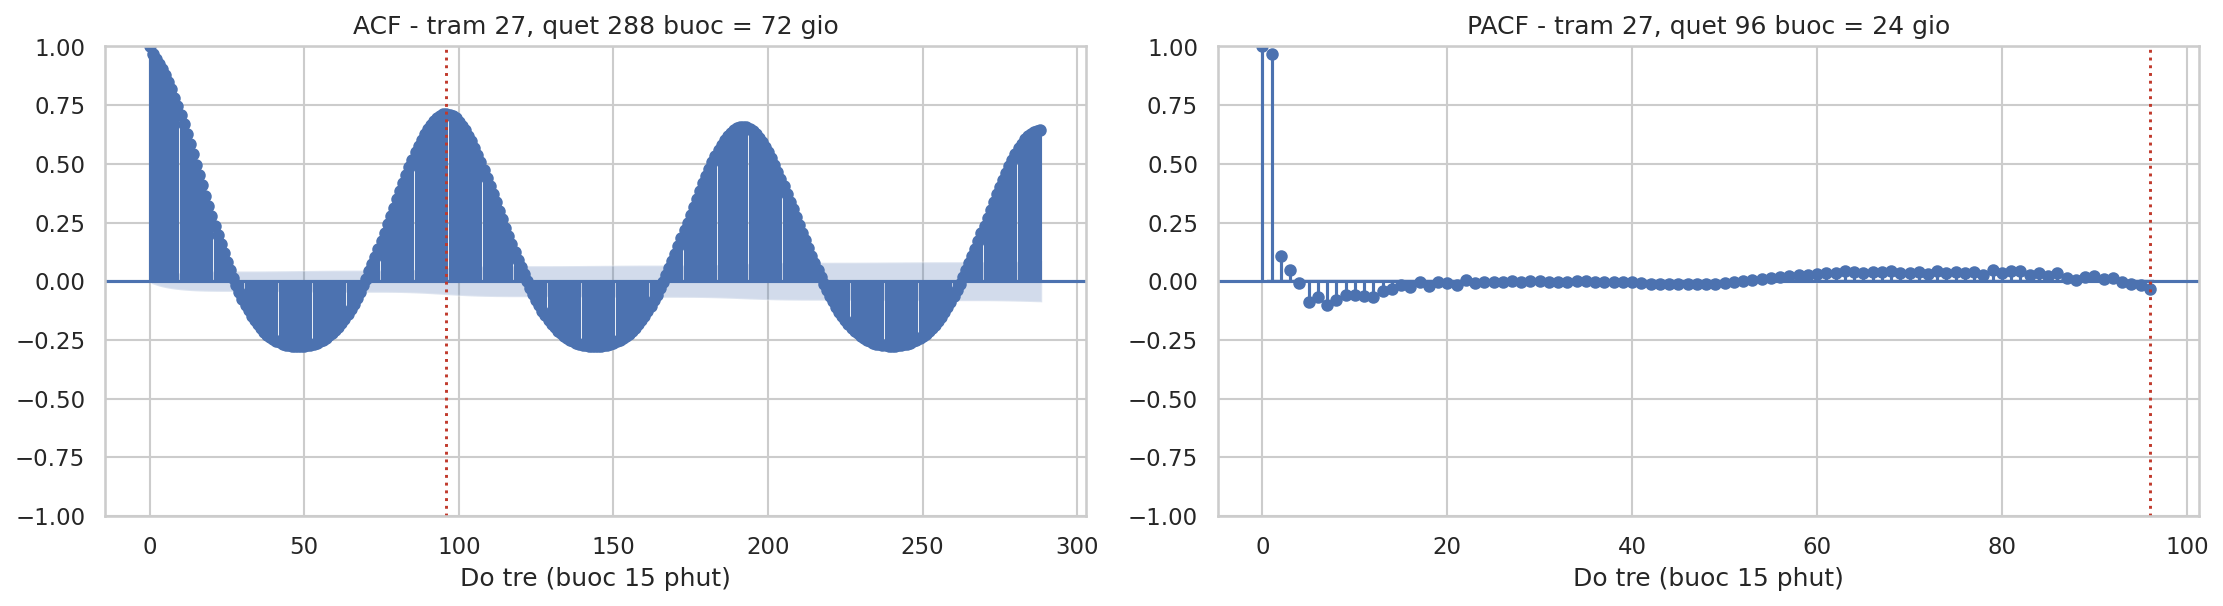


--- TU TUONG QUAN TAI CAC MOC DANG CHU Y ---
   lag   1 (   15 phut =    0 gio): ACF = +0.9690
   lag   4 (   60 phut =    1 gio): ACF = +0.9035
   lag  96 ( 1440 phut =   24 gio): ACF = +0.7134
   lag 192 ( 2880 phut =   48 gio): ACF = +0.6614
   lag 288 ( 4320 phut =   72 gio): ACF = +0.6466

Da ghi: ../../data/model/v5/02_EDA/eda_acf_pacf.png


In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

chuoi = _d.set_index(TS)[TARGET].astype(float).asfreq("15min").fillna(0.0)
print(f"Chuoi tram {_s}: {len(chuoi):,} buoc lien tuc")

fig, ax = plt.subplots(1, 2, figsize=(15, 4.2))
plot_acf(chuoi, lags=288, ax=ax[0], alpha=0.05)
ax[0].set_title(f"ACF - tram {_s}, quet 288 buoc = 72 gio")
ax[0].set_xlabel("Do tre (buoc 15 phut)")
plot_pacf(chuoi, lags=96, ax=ax[1], alpha=0.05, method="ywm")
ax[1].set_title(f"PACF - tram {_s}, quet 96 buoc = 24 gio")
ax[1].set_xlabel("Do tre (buoc 15 phut)")
for a in ax:
    a.axvline(96, color="#c0392b", ls=":", lw=1.4)
plt.tight_layout()
plt.savefig(f"{RA}/eda_acf_pacf.png", bbox_inches="tight")
plt.show()

print("\n--- TU TUONG QUAN TAI CAC MOC DANG CHU Y ---")
for k in (1, 4, 96, 192, 288):
    print(f"   lag {k:>3} ({k*15:>5} phut = {k*15/60:>4.0f} gio): ACF = {chuoi.autocorr(k):+.4f}")
print(f"\nDa ghi: {RA}/eda_acf_pacf.png")

## 6. Ma trận tương quan Spearman — chỉ tính ban ngày

Tính trên phạm vi **đo thật ban ngày**, vì gộp cả ban đêm sẽ kéo tương quan lên một cách giả tạo
(mọi biến đều bằng 0 cùng lúc).

Tinh tren 606,112 dong do that ban ngay

--- TUONG QUAN VOI SAN LUONG ---
Bien                          Spearman   Pearson
shortwave_radiation            +0.6043   +0.3531
diffuse_solar_radiation        +0.3809   +0.1794
direct_normal_irradiance       +0.5513   +0.3234
temperature_c                  +0.2639   +0.1642
cloud_cover_total              -0.1591   -0.0944

--- DOI CHIEU: gop ca ban dem (1,479,880 dong) ---
Bien                          ban ngay    ca dem    chenh
shortwave_radiation            +0.6043   +0.9112  +0.3069
diffuse_solar_radiation        +0.3809   +0.8837  +0.5028
direct_normal_irradiance       +0.5513   +0.8877  +0.3364
temperature_c                  +0.2639   +0.4527  +0.1888
cloud_cover_total              -0.1591   +0.0280  +0.1870


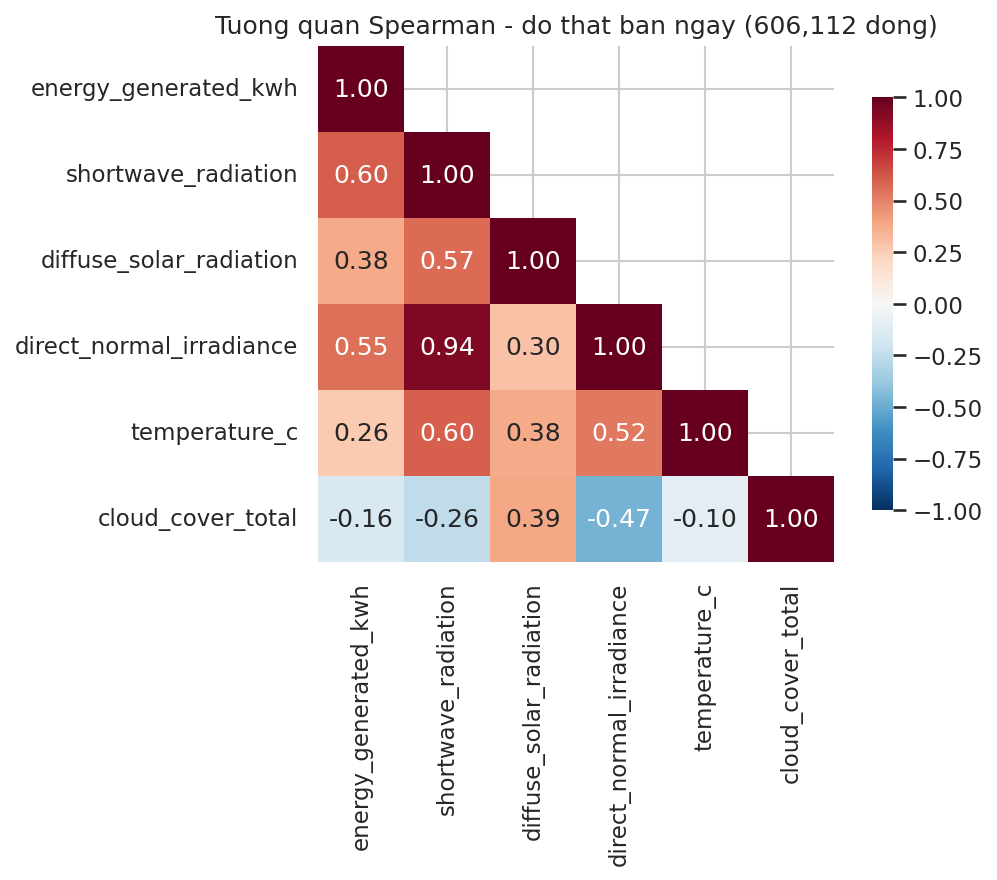


Da ghi: ../../data/model/v5/02_EDA/eda_tuong_quan_spearman.png


In [8]:
COT_SO = [TARGET, "shortwave_radiation", "diffuse_solar_radiation",
          "direct_normal_irradiance", "temperature_c", "cloud_cover_total"]
z = pham_vi["do that ban ngay"][COT_SO].dropna()
print(f"Tinh tren {len(z):,} dong do that ban ngay")

sp = z.corr(method="spearman")
pe = z.corr(method="pearson")

print("\n--- TUONG QUAN VOI SAN LUONG ---")
print(f"{'Bien':<28}{'Spearman':>10}{'Pearson':>10}")
for c in COT_SO[1:]:
    print(f"{c:<28}{sp.loc[TARGET, c]:>+10.4f}{pe.loc[TARGET, c]:>+10.4f}")

# doi chieu: neu gop ca ban dem thi tuong quan doi bao nhieu
z2 = df[COT_SO].dropna()
print(f"\n--- DOI CHIEU: gop ca ban dem ({len(z2):,} dong) ---")
sp2 = z2.corr(method="spearman")
print(f"{'Bien':<28}{'ban ngay':>10}{'ca dem':>10}{'chenh':>9}")
for c in COT_SO[1:]:
    a, b = sp.loc[TARGET, c], sp2.loc[TARGET, c]
    print(f"{c:<28}{a:>+10.4f}{b:>+10.4f}{b-a:>+9.4f}")

fig, ax = plt.subplots(figsize=(7.4, 6))
mask = np.triu(np.ones_like(sp, dtype=bool), k=1)
sns.heatmap(sp, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-1, vmax=1, square=True, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title(f"Tuong quan Spearman - do that ban ngay ({len(z):,} dong)")
plt.tight_layout()
plt.savefig(f"{RA}/eda_tuong_quan_spearman.png", bbox_inches="tight")
plt.show()
sp.to_csv(f"{RA}/eda_tuong_quan_spearman.csv")
print(f"\nDa ghi: {RA}/eda_tuong_quan_spearman.png")

## 7. Ghi chú về chẩn đoán đa cộng tuyến

Hệ số phóng đại phương sai (VIF) **không tính ở notebook này**. VIF cần toàn bộ đặc trưng đã
sinh xong, nên nó nằm ở **`04_vif_diagnostics.ipynb`** — chạy sau `03_1`, `03_2` và `03_3`.
Báo cáo trích kết quả VIF từ đúng notebook đó, không trích từ đây.

In [9]:
print("=" * 72)
print("HOAN TAT 02_EDA - PHAM VI: CHI TAP HUAN LUYEN")
print("=" * 72)
for f in sorted(os.listdir(RA)):
    print(f"   {RA}/{f}")

HOAN TAT 02_EDA - PHAM VI: CHI TAP HUAN LUYEN
   ../../data/model/v5/02_EDA/eda_acf_pacf.png
   ../../data/model/v5/02_EDA/eda_mau_hinh_phat_dien.png
   ../../data/model/v5/02_EDA/eda_phan_bo_don_bien.png
   ../../data/model/v5/02_EDA/eda_thong_ke_mo_ta.csv
   ../../data/model/v5/02_EDA/eda_tuong_quan_spearman.csv
   ../../data/model/v5/02_EDA/eda_tuong_quan_spearman.png
